<a href="https://colab.research.google.com/github/Tilly-11/Quantitative-finance-projects/blob/main/value_at_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Environment Setup
!pip install yfinance scipy


In [2]:
# Import core data, math, and statistical packages
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm


In [3]:
def fetch_and_clean_returns(tickers, start_date, end_date):
    """Downloads historical data and returns daily percentage changes."""
    raw_data = yf.download(tickers, start=start_date, end=end_date)
    df = raw_data['Close']

    # Clean missing data if necessary
    if df.isnull().values.any():
        df = df.fillna(method='ffill').fillna(method='bfill')

    returns = df.pct_change().dropna()
    return returns

In [4]:
def calculate_historical_var(returns, weights, portfolio_value, confidence_level=0.95):
    """Calculates the percentage and dollar Value-at-Risk using historical simulation."""
    # Convert weights list/array into a numpy array for matrix math
    weights_array = np.array(weights)

    # Calculate weighted daily returns of the portfolio
    portfolio_returns = returns.dot(weights_array)

    # Find the percentile cutoff
    var_percentile = np.percentile(portfolio_returns, (1 - confidence_level) * 100)
    dollar_var = var_percentile * portfolio_value

    return var_percentile, dollar_var, portfolio_returns

In [6]:
def plot_var_distribution(portfolio_returns, var_percentile, output_filename='portfolio_var_distribution.png'):
    """Generates and saves a publication-quality histogram of the risk profile."""
    plt.figure(figsize=(10,6))

    # Plot histogram
    plt.hist(portfolio_returns * 100, bins=50, alpha=0.75, color='royalblue', edgecolor='black')

    # Draw risk boundary line
    plt.axvline(var_percentile * 100, color='crimson', linestyle='--', linewidth=2,
                label=f'Historical VaR Threshold ({var_percentile*100:.2f}%)')

    plt.xlabel('Daily Portfolio Return (%)', fontsize=12)
    plt.ylabel('Frequency (Days)', fontsize=12)
    plt.title('Portfolio Returns Distribution & Value-at-Risk (VaR) Threshold', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.3)

    # Save crisp image file
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_9307/3222666132.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed



--- Value-at-Risk Execution Results ---
Risk Threshold (Percentage): -3.71%
Max Expected 1-Day Loss: $3,705.10


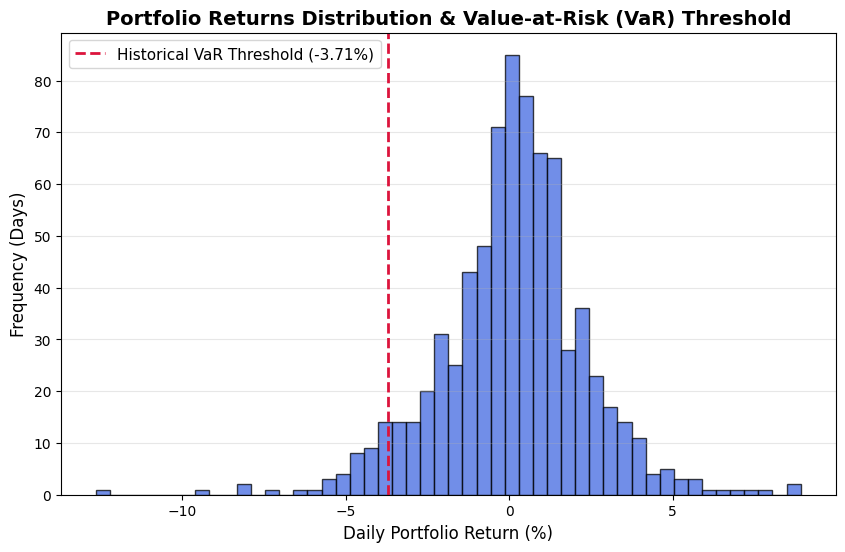

In [11]:
# 1. Define configuration settings
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
start = '2020-01-01'
end = '2023-01-01'
budget = 100000
confidence = 0.95

#Assume this is the 'clean_weights' dictionary output generated by Portfolio Optimization[optimize_portfolio]
clean_weights = {'AAPL': 0.15, 'MSFT': 0.35, 'GOOGL': 0.10, 'AMZN': 0.20, 'TSLA': 0.20}

#Extract the numbers in the exact order of your ticker columns
ordered_weights = [clean_weights[ticker] for ticker in tickers]


#Run the pipeline functions
historical_returns = fetch_and_clean_returns(tickers, start, end)

var_pct, var_dlr, port_ret = calculate_historical_var(
    returns=historical_returns,
    weights=ordered_weights,
    portfolio_value=budget,
    confidence_level=confidence
)

#Print the results
print("\n--- Value-at-Risk Execution Results ---")
print(f"Risk Threshold (Percentage): {var_pct * 100:.2f}%")
print(f"Max Expected 1-Day Loss: ${abs(var_dlr):,.2f}")

#Generate visual plot
plot_var_distribution(port_ret, var_pct)
